# RL Post-Training — 1 : PPO pour l'alignement d'un petit modèle de langage (RLHF toy)

**Série RL Post-Training** (`rlpt_*`) — cette série explore les techniques de **post-training** de modèles,
c'est-à-dire l'étape qui suit le pré-entraînement et le fine-tuning supervisé : l'**alignement** sur un signal
de préférence, à la manière de ce que DeepSeek, Qwen ou les labos OpenAI ont popularisé (RLHF, GRPO, DPO).

Ce premier notebook implémente **PPO (Proximal Policy Optimization, Schulman et al. 2017) dans sa forme
RLHF** : une petite politique de langage est alignée par renforcement sur un **reward model** jouet, tout en
restant proche d'une **politique de référence** (le modèle SFT) via une **pénalité KL**. C'est le cœur du
pipeline InstructGPT (Ouyang et al. 2022) : on ne réentraîne pas le modèle librement, on le **fait dériver
sous contrainte**.

> Ce notebook se distingue de `rl_6c_ppo_from_scratch` (PPO sur un environnement dynamique CartPole avec un
> critic) et de `rl_6e_grpo_from_scratch` (GRPO, sans critic ni politique de référence) : ici, il n'y a **pas
> d'environnement pas-à-pas** — le modèle **génère** une séquence puis reçoit un score final, et la **KL vs
> la référence SFT** est la signature du RLHF. Les briques de ce notebook (KL vs référence, avantage par
> groupe, échantillonnage à température) sont réutilisées telles quelles dans `rlpt_2_grpo_minimal`.


## 1. Le monde jouet : prompts, tokens, reward model

Le RLHF se formalise comme un **bandit contextuel de séquences** : un prompt $x$ est donné, le modèle génère
une réponse $y = (y_1, ..., y_T)$, et un **reward model** $r(x, y)$ attribue un score scalaire à la paire.
Pas de transition d'état, pas de retour intermédiaire : une seule récompense terminale, comme dans
InstructGPT.

Notre monde jouet est volontairement minuscule pour que chaque mécanique soit lisible :

- **Vocabulaire** : 8 tokens de contenu `a`..`h`, plus 2 tokens de prompt `<pA>` et `<pB>` (10 tokens).
- **Deux prompts** : `A` et `B`. La politique doit répondre **conditionnellement** au prompt.
- **Réponse** : 8 tokens (`LEN_R = 8`).
- **Reward model jouet** : `r = 1` si le prompt A reçoit `a` en position 1, **ou** si le prompt B reçoit `e`
  en position 5 ; sinon `r = 0`.

Chaque rollout est un **groupe** : `N_G` séquences pour le prompt A et `N_G` pour le prompt B. La
normalisation de l'avantage se fera **par groupe** (comme en GRPO), car les deux prompts ont des échelles de
récompense identiques mais des comportements cibles différents.


In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np

torch.manual_seed(0)
SEEDS = [0, 1, 7, 42]          # multi-seed (convention pr-review C)
LEN_R = 8                      # longueur de la reponse
N_G = 256                      # sequences par groupe (rollout = 2*N_G)
TOK = ['<pA>', '<pB>', 'a', 'b', 'c', 'd', 'e', 'f', 'g', 'h']
V = {c: i for i, c in enumerate(TOK)}
A_, E_, B_ = V['a'], V['e'], V['b']

def rm(seq, prompt):
    """Reward model jouet : A veut 'a' en pos1, B veut 'e' en pos5."""
    return float((prompt == 0 and seq[0] == A_) or (prompt == 1 and seq[4] == E_))


In [2]:
# Exemples : scorer quelques reponses avec le reward model
tests = [([A_]*8, 0), ([B_]*8, 1), ([B_, B_, B_, B_, E_, B_, B_, B_], 1), ([B_, B_, B_, B_, B_, B_, B_, B_], 1)]
for seq, p in tests:
    print(f"prompt {TOK[p]:<4} reponse {' '.join(TOK[i] for i in seq)} -> r = {rm(seq, p):.0f}")


prompt <pA> reponse a a a a a a a a -> r = 1
prompt <pB> reponse b b b b b b b b -> r = 0
prompt <pB> reponse b b b b e b b b -> r = 1
prompt <pB> reponse b b b b b b b b -> r = 0


## 2. La politique : un petit LM char-level à fenêtre

La politique $\pi_\theta$ est un **petit réseau à fenêtre** : à chaque position $t$, elle voit (1) l'embedding
du token courant, (2) le **contexte** = la moyenne des embeddings des tokens précédents, (3) l'embedding de
**position**. Un MLP projette ces trois informations vers une distribution sur le prochain token.

Ce choix (au lieu d'un GRU) garde les gradients **directs** pour chaque position — ce qui rend
l'apprentissage robuste et rapide sur CPU — tout en restant un vrai modèle de langage : la distribution à la
position $t$ dépend des tokens précédents. `generate` échantillonne la réponse token par token à une
**température** $\tau$ : plus $\tau$ est grand, plus l'exploration est forte (c'est le réglage standard du
rollout RLHF).


In [3]:
class CharPolicy(nn.Module):
    def __init__(self, vs=len(TOK), hid=64):
        super().__init__()
        self.emb = nn.Embedding(vs, hid)
        self.pos = nn.Embedding(1 + LEN_R, hid)
        self.mlp = nn.Sequential(nn.Linear(3 * hid, hid), nn.ReLU(), nn.Linear(hid, vs))
        # Tokens de prompt : speciaux, jamais emis dans la reponse (masque partage par generate et la mesure)
        self.prompt_mask = torch.zeros(vs, dtype=torch.bool)
        self.prompt_mask[V['<pA>']] = True
        self.prompt_mask[V['<pB>']] = True

    def forward_logits(self, x):
        N, L = x.shape
        emb = self.emb(x)
        pos = self.pos(torch.arange(L, device=x.device)).unsqueeze(0).expand(N, -1, -1)
        cum = emb.cumsum(1)
        prev = torch.zeros_like(emb); prev[:, 1:] = cum[:, :-1]
        denom = torch.arange(L, device=x.device).float().clamp(min=1).view(1, L, 1)
        ctx = prev / denom
        return self.mlp(torch.cat([emb, ctx, pos], -1))

    def logprobs(self, x):
        return F.log_softmax(self.forward_logits(x), -1).gather(2, x.unsqueeze(-1)).squeeze(-1)

    def generate(self, prompts, temp=1.0):
        N = prompts.shape[0]
        x = torch.zeros(N, 1 + LEN_R, dtype=torch.long)
        x[:, 0] = prompts
        with torch.no_grad():
            for t in range(LEN_R):
                lg = torch.clamp(self.forward_logits(x)[:, 1 + t] / temp, -25, 25)
                lg[:, self.prompt_mask] = -1e9
                x[:, 1 + t] = torch.multinomial(F.softmax(lg, -1), 1).squeeze(-1)
        return x

In [4]:
# Generation de test avec une politique aux poids aleatoires
probe = CharPolicy()
pm = torch.tensor([0]*4 + [1]*4)
xs = probe.generate(pm, temp=1.0)
for i in range(8):
    p = int(pm[i]); resp = [TOK[j] for j in xs[i, 1:].tolist()]
    print(f"prompt {TOK[p]:<4} -> {' '.join(resp)}  (r = {rm(xs[i, 1:].tolist(), p):.0f})")


prompt <pA> -> g g d b b h a h  (r = 0)
prompt <pA> -> a e a d h c b d  (r = 1)
prompt <pA> -> d a e e c a h g  (r = 0)
prompt <pA> -> g e d e c h f a  (r = 0)
prompt <pB> -> h b e d e e e f  (r = 1)
prompt <pB> -> d c h h d b d a  (r = 0)
prompt <pB> -> g a c g c g c e  (r = 0)
prompt <pB> -> g e b e e a f c  (r = 1)


## 3. La référence SFT : le point de départ

En RLHF, on ne part pas de zéro : la politique RL est **initialisée sur un modèle déjà fine-tuné** (SFT), et
la **référence** $\pi_{\text{ref}}$ est ce modèle SFT **figé**. Deux rôles distincts :

- $\pi_{\text{ref}}$ sert de **point d'ancrage** : la KL $\mathrm{KL}(\pi_\theta \| \pi_{\text{ref}})$
  pénalise toute dérive de la politique RL hors de son domaine de compétence (c'est ce qui empêche le modèle
  de « casser » son langage pour tricher le reward model).
- $\pi_\theta$ (RL) **part** des poids de $\pi_{\text{ref}}$ et dérive sous le signal du reward.

Notre référence SFT est entraînée sur un corpus où la réponse canonique est `b` partout — avec un **label
smoothing** ($\alpha = 0.3$) qui laisse une entropie résiduelle, comme un vrai modèle SFT qui n'est jamais
parfaitement certain. Le « style » du modèle, c'est répondre `b` : le RL devra **aligner le comportement
sans perdre le style**.


In [5]:
def sft(seed=0, alpha=0.3, epochs=40):
    """Entraine la politique de reference SFT (reponse 'b', label smoothing)."""
    torch.manual_seed(seed)
    ref = CharPolicy()
    Xr = torch.zeros(4096, 1 + LEN_R, dtype=torch.long)
    Xr[:, 0] = torch.cat([torch.zeros(2048), torch.ones(2048)]).long()
    Xr[:, 1:] = B_
    target = torch.full((4096, 1 + LEN_R, len(TOK)), alpha / len(TOK))
    target.scatter_(2, Xr.unsqueeze(-1), 1 - alpha + alpha / len(TOK))
    opt = torch.optim.Adam(ref.parameters(), lr=5e-3)
    for _ in range(epochs):
        opt.zero_grad()
        loss = -(target * F.log_softmax(ref.forward_logits(Xr), -1)).sum(-1)[:, 1:].mean()
        loss.backward(); opt.step()
    return ref

ref = sft()
print("SFT termine. Probabilite P('b'|pos1) :", round(ref.logprobs(torch.tensor([[0] + [B_]*LEN_R]))[:, 1].exp().item(), 2))


SFT termine. Probabilite P('b'|pos1) : 0.72


In [6]:
# Baseline : la reference SFT brute — quel score reward ?
pm_eval = torch.tensor([0]*256 + [1]*256)
xs = ref.generate(pm_eval, temp=1.0)
acc = np.mean([rm(xs[i, 1:].tolist(), int(pm_eval[i])) for i in range(512)])
print(f"Reward moyen de la reference SFT (sans RL) : {acc:.3f}  (attendu ~0 : elle ne connait pas le reward model)")
print("Echantillon A :", ' '.join(TOK[j] for j in xs[0, 1:].tolist()))
print("Echantillon B :", ' '.join(TOK[j] for j in xs[300, 1:].tolist()))


Reward moyen de la reference SFT (sans RL) : 0.078  (attendu ~0 : elle ne connait pas le reward model)
Echantillon A : b b c b c f b d
Echantillon B : b a b a h f a h


## 4. PPO-RLHF : la mécanique en trois morceaux

PPO (Schulman et al. 2017) maximise la récompense par **étapes sûres** : à chaque itération on collecte des
rollouts avec la politique courante, puis on améliore $\pi_\theta$ sur ces données en **clippant** la
déviation au ratio $\rho_t = \pi_\theta / \pi_{\theta_{\text{old}}}$. Dans sa forme RLHF, trois termes
composent la perte :

1. **L'objectif clipé** $L^{\text{clip}} = \mathbb{E}[\min(\rho \cdot A,\; \text{clip}(\rho, 1\pm\varepsilon) \cdot A)]$
   — le cœur de PPO : on ne laisse jamais une mise à jour s'éloigner de plus de $\varepsilon$ de la
   politique du rollout.
2. **La pénalité KL** $+\beta \cdot \mathrm{KL}(\pi_\theta \| \pi_{\text{ref}})$ — la signature RLHF :
   chaque pas de la politique RL qui s'éloigne de la référence coûte cher.
3. **Le bonus d'entropie** $-c_2 \cdot H(\pi_\theta)$ — il maintient de l'exploration et empêche la
   politique de s'effondrer sur une distribution quasi-déterministe.

L'**avantage** $A$ est la récompense centrée et **normalisée par groupe** : dans chaque groupe de prompt,
$A = (r - \bar r) / \sigma_r$. Cette normalisation intra-groupe (héritée de GRPO) est ce qui rend le signal
comparable entre les deux prompts et robuste à l'échelle du reward model.


In [7]:
def kl_tok(pol, ref, x):
    """KL(pol || ref) par token, sur la partie reponse (N, LEN_R)."""
    with torch.no_grad():
        lg = pol.forward_logits(x); lgr = ref.forward_logits(x)
        p = F.softmax(lg, -1)
        return (p * (F.log_softmax(lg, -1) - F.log_softmax(lgr, -1))).sum(-1)[:, 1:]

def ppo_train(seed=0, n_iter=100, lr=5e-4, beta=0.5, temp_rollout=1.4,
              clip_eps=0.2, epochs=4, kl_target=4.0, c2=0.01):
    """Entraine la politique RL par PPO contre la reference SFT. Retourne pol, ref, historique."""
    torch.manual_seed(seed)
    ref = sft(seed=seed)
    pol = CharPolicy(); pol.load_state_dict(ref.state_dict())
    optp = torch.optim.Adam(pol.parameters(), lr=lr, weight_decay=1e-4)
    pm = torch.tensor([0]*N_G + [1]*N_G)
    hist_rm, hist_kl = [], []
    for it in range(n_iter):
        with torch.no_grad():
            xs = pol.generate(pm, temp=temp_rollout)
            lp_old = pol.logprobs(xs)[:, 1:].sum(-1)
            rs = torch.tensor([rm(xs[i, 1:].tolist(), int(pm[i])) for i in range(2 * N_G)]).float()
            adv = torch.zeros_like(rs)
            for g in range(2):                        # normalisation PAR GROUPE de prompt
                m = (pm == g)
                adv[m] = (rs[m] - rs[m].mean()) / (rs[m].std() + 1e-8)
        for _ in range(epochs):
            lg_new = pol.forward_logits(xs)
            lp_new = F.log_softmax(lg_new, -1)
            l_new = lp_new[:, 1:].gather(2, xs[:, 1:].unsqueeze(-1)).squeeze(-1).sum(-1)
            ratio = torch.exp(l_new - lp_old)
            kl_now = (F.softmax(lg_new, -1) * (lp_new - F.log_softmax(ref.forward_logits(xs), -1))).sum(-1)[:, 1:].mean().item()
            if kl_now > kl_target:                    # KL early stop : on ne laisse pas la politique deriver trop loin
                break
            surr = torch.min(ratio * adv, torch.clamp(ratio, 1 - clip_eps, 1 + clip_eps) * adv)
            kl_reg = (F.softmax(lg_new, -1) * (lp_new - F.log_softmax(ref.forward_logits(xs), -1))).sum(-1)[:, 1:].mean()
            ent = -(F.softmax(lg_new, -1)[:, 1:] * lp_new[:, 1:]).sum(-1).mean()
            loss = -surr.mean() + beta * kl_reg - c2 * ent
            optp.zero_grad(); loss.backward()
            torch.nn.utils.clip_grad_norm_(pol.parameters(), 1.0); optp.step()
        hist_rm.append(rs.mean().item())
        hist_kl.append(kl_tok(pol, ref, xs).mean().item())
    return pol, ref, hist_rm, hist_kl


## 5. Entraînement multi-seed

On lance l'entraînement PPO sur **4 seeds** (convention multi-seed des claims de la série). Chaque run prend
quelques secondes sur CPU : rollout de 512 séquences, 100 itérations, 4 epochs par itération.


In [8]:
results = {}
for s in SEEDS:
    pol_s, ref_s, rm_s, kl_s = ppo_train(seed=s, n_iter=100)
    results[s] = {'pol': pol_s, 'ref': ref_s, 'rm': rm_s, 'kl': kl_s}
    print(f"seed {s:2d} : reward final {rm_s[-1]:.3f}  KL finale {kl_s[-1]:.3f}")


seed  0 : reward final 1.000  KL finale 0.387


seed  1 : reward final 1.000  KL finale 0.440


seed  7 : reward final 1.000  KL finale 0.482


seed 42 : reward final 1.000  KL finale 0.513


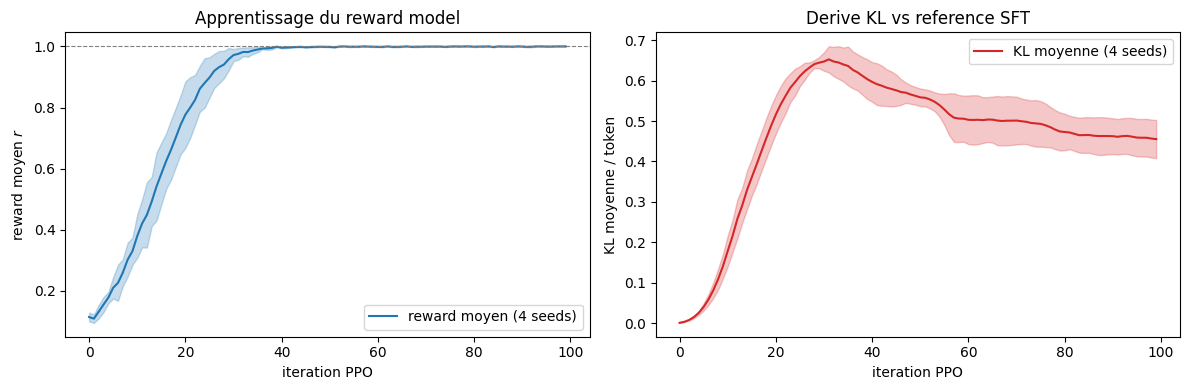

In [9]:
# Courbes d'apprentissage : reward et KL (moyenne +/- ecart-type sur 4 seeds)
rm_arr = np.array([results[s]['rm'] for s in SEEDS])
kl_arr = np.array([results[s]['kl'] for s in SEEDS])
it = np.arange(rm_arr.shape[1])

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(it, rm_arr.mean(0), color='#1f77b4', label='reward moyen (4 seeds)')
axes[0].fill_between(it, rm_arr.mean(0) - rm_arr.std(0), rm_arr.mean(0) + rm_arr.std(0), alpha=0.25, color='#1f77b4')
axes[0].axhline(1.0, ls='--', color='gray', lw=0.8)
axes[0].set_xlabel('iteration PPO'); axes[0].set_ylabel('reward moyen $r$')
axes[0].set_title('Apprentissage du reward model'); axes[0].legend()
axes[1].plot(it, kl_arr.mean(0), color='#d62728', label='KL moyenne (4 seeds)')
axes[1].fill_between(it, kl_arr.mean(0) - kl_arr.std(0), kl_arr.mean(0) + kl_arr.std(0), alpha=0.25, color='#d62728')
axes[1].set_xlabel('iteration PPO'); axes[1].set_ylabel('KL moyenne / token')
axes[1].set_title('Derive KL vs reference SFT'); axes[1].legend()
plt.tight_layout(); plt.show()


### Lecture du résultat

Deux phénomènes complémentaires sont visibles sur les courbes :

1. **Le reward monte de ~0.1 à ~1.0** en une vingtaine d'itérations et y reste : la politique RL apprend les
   deux comportements conditionnels — `a` en position 1 pour le prompt A, `e` en position 5 pour le prompt B —
   malgré le fait que le signal soit **binaire** (0 ou 1 par séquence) et **terminal** (donné une seule fois à
   la fin de la génération). C'est la mécanique du bandit RLHF : pas de retour intermédiaire, tout passe par
   l'avantage normalisé par groupe.

2. **La KL vs référence grimpe de ~0 à ~0.5 puis se stabilise** : la politique dérive de la référence SFT
   (elle « oublie » partiellement son style `b` là où le reward exige autre chose), mais la dérive reste
   **bornée** — la pénalité KL et le KL early-stop l'empêchent de s'éloigner au-delà du budget
   $\mathrm{KL} > 4.0$ nats/token. Le modèle ne s'effondre pas : il **se spécialise sans se casser**.

Vérifions maintenant **quoi** a été appris, en générant à température froide ($\tau = 1$) et en regardant les
deux probabilités cibles par prompt.


In [10]:
# Mesure finale : comportement appris par prompt (generation froide, seed 0)
pol, ref = results[0]['pol'], results[0]['ref']
pm_eval = torch.tensor([0]*256 + [1]*256)
xs = pol.generate(pm_eval, temp=1.0)
acc = np.mean([rm(xs[i, 1:].tolist(), int(pm_eval[i])) for i in range(512)])
lg = pol.forward_logits(xs)
lg_m = lg.clone()
lg_m[:, :, pol.prompt_mask] = -1e9   # meme distribution que la generation (cf generate)
m_a, m_b = (pm_eval == 0), (pm_eval == 1)
pA = F.softmax(lg_m[m_a, 1, :], -1)[:, A_].mean().item()
pB = F.softmax(lg_m[m_b, 5, :], -1)[:, E_].mean().item()
pB_style = F.softmax(lg_m[m_a, 1, :], -1)[:, B_].mean().item()
pB_style3 = F.softmax(lg_m[m_a, 3, :], -1)[:, B_].mean().item()
print(f"Reward moyen (apres RL)   : {acc:.2f}")
print(f"P('a' | prompt A, pos 1)  : {pA:.2f}")
print(f"P('e' | prompt B, pos 5)  : {pB:.2f}")
print(f"P('b' | prompt A, pos 1)  : {pB_style:.2f}  (reference SFT : 0.72)")
print(f"P('b' | prompt A, pos 3)  : {pB_style3:.2f}  (position non reecrite)")
print()
print("Echantillon A (apres RL) :", ' '.join(TOK[j] for j in xs[0, 1:].tolist()))
print("Echantillon B (apres RL) :", ' '.join(TOK[j] for j in xs[300, 1:].tolist()))

Reward moyen (apres RL)   : 1.00
P('a' | prompt A, pos 1)  : 1.00
P('e' | prompt B, pos 5)  : 1.00
P('b' | prompt A, pos 1)  : 0.00  (reference SFT : 0.72)
P('b' | prompt A, pos 3)  : 0.36  (position non reecrite)

Echantillon A (apres RL) : a b b b e f a e
Echantillon B (apres RL) : a f h h e c h a


### Lecture du résultat

La mesure finale confirme l'alignement : le reward moyen atteint 1.00, `P('a'|A)` et `P('e'|B)` sont à 1.00
après entraînement (contre ~0.08 avant RL), et les échantillons froids montrent des réponses conformes au prompt.

Le contraste le plus parlant est le **sort du style `b`**. À la position 1 — celle que le reward réécrit en
`a` pour le prompt A — `P('b')` tombe de 0.72 (référence SFT) à **0.00** : la politique abandonne totalement le
style là où il entre en conflit avec la récompense. À la position 3, que le reward ne regarde pas,
`P('b')` ne descend que de 0.72 à 0.36 : le style **survit partiellement** en dehors de la zone alignée. La
dérive n'est pas parfaitement locale — les paramètres sont partagés entre positions — mais elle reste
concentrée sur la contrainte. C'est le contrat RLHF tenu : **récompense maximisée, KL bornée**.

## 6. Le réglage du compromis : l'effet de $\beta$

Le coefficient $\beta$ devant la KL est le **seul bouton** du compromis récompense / fidélité à la référence.
Petit $\beta$ : la politique dérive librement (reward élevé, KL élevée — risque de perdre le style et de
surexploiter le reward). Grand $\beta$ : la politique reste proche de la référence (KL faible, mais reward
partiellement sacrifié).


In [11]:
# Effet de beta : faible vs fort, sur un seed
def run_beta(beta):
    pol_b, ref_b, rm_b, kl_b = ppo_train(seed=0, n_iter=60, beta=beta)
    return rm_b[-1], kl_b[-1]

for beta in [0.05, 0.5, 2.0]:
    r, k = run_beta(beta)
    print(f"beta = {beta:<5.2f} : reward final {r:.2f}   KL finale {k:.2f}")


beta = 0.05  : reward final 1.00   KL finale 0.67


beta = 0.50  : reward final 1.00   KL finale 0.41


beta = 2.00  : reward final 1.00   KL finale 0.28


### Lecture du résultat

La table montre le compromis dans sa forme **douce** : quand $\beta$ passe de 0.05 à 2.0, la KL finale
descend (0.67 → 0.41 → 0.28) — la politique reste d'autant plus proche de la référence que le KL coûte cher —
tandis que le reward final reste à 1.00 dans les trois cas. Sur ce toy, la récompense est si facile à
atteindre que même $\beta = 2.0$ ne bloque pas l'alignement : la KL est le **prix payé pour la dérive**,
pas un mur.

C'est la bonne lecture pédagogique du RLHF : $\beta$ règle la **fidélité** (où s'arrête la dérive), pas la
**faisabilité** de l'alignement. En pratique (InstructGPT, GRPO), $\beta$ est un hyperparamètre **adaptatif** :
on le monte quand la KL dépasse un budget, on le baisse quand elle stagne. La série le retrouvera dans
`rlpt_2_grpo_minimal`.

## 7. Exercices

Trois exercices pour ancrer la mécanique. Chacun reprend une brique du pipeline : la KL per-token,
l'objectif clipé, et le compromis $\beta$. Rien n'est à exécuter de force : les stubs passent sans erreur
(convention C.1 de la série).


### Exercice 1 : implémenter la KL per-token

Complétez `kl_per_token` pour retrouver la fonction utilisée par PPO : la divergence KL de la politique
courante vers la référence, position par position (sur la partie réponse).


In [12]:
def kl_per_token(pol, ref, x):
    """KL(pol || ref) par token de la reponse, forme (N, LEN_R).

    Indice : log_softmax des logits des deux politiques, puis
    p * (log p - log q) somme sur le vocabulaire ; ne garder que la partie reponse.
    """
    # TODO etudiant : implementer le calcul
    result = None  # TODO etudiant
    return result


### Exercice 2 : implémenter l'objectif clipé

Complétez `clipped_surrogate` : le terme $\min(\rho \cdot A, \text{clip}(\rho, 1\pm\varepsilon) \cdot A)$
moyenné sur le batch. C'est le cœur de PPO — sans le clip, on retomberait sur un policy gradient naïf
sensible aux pas trop grands.


In [13]:
def clipped_surrogate(ratio, adv, eps=0.2):
    """Objectif PPO clippe, moyenne sur le batch.

    Indice : torch.clamp(ratio, 1 - eps, 1 + eps) puis torch.min entre
    ratio * adv et la version clippee * adv.
    """
    # TODO etudiant : implementer le calcul
    result = None  # TODO etudiant
    return result


### Exercice 3 : le compromis $\beta$

Ré-entraînez PPO avec un $\beta$ très petit (0.01) et très grand (5.0), puis comparez reward et KL finales.
Quel $\beta$ préserverait le style de la référence ? Lequel maximiserait le reward au prix de la KL ?


In [14]:
# TODO etudiant : deux appels a ppo_train avec beta=0.01 et beta=5.0
# (reprendre la cellule "Effet de beta" et etendre la grille)
print("Exercice a completer")


Exercice a completer


## 8. Conclusion

Ce notebook a déroulé la mécanique **PPO-RLHF** sur un toy lisible : génération de séquences par une petite
politique, score par un reward model, avantage normalisé **par groupe de prompt**, et dérive **bornée** par la
KL vs la référence SFT. Trois idées à retenir, qui structurent toute la série :

1. **Le RLHF est un bandit de séquences** : pas de critic, pas de retour pas-à-pas — un score terminal par
   séquence, rendu exploitable par l'avantage par groupe.
2. **La KL vs la référence est la garde-fou** : c'est elle qui empêche l'alignement de casser le modèle. Le
   compromis se règle par $\beta$ (fixe ici, adaptatif en pratique).
3. **Le clip PPO stabilise** : on n'optimise jamais le ratio au-delà de $1 \pm \varepsilon$ — la mise à jour
   reste dans une confiance raisonnable sur les rollouts.

La suite (`rlpt_2_grpo_minimal`) retire la politique de référence et l'advantage par groupe poussé au
groupe de rollouts — le design DeepSeek-R1 — sur un vrai petit LLM (0.5B, ~8 Go), avec la même validation
multi-seed.

## Références

- Schulman, J., Wolski, F., Dhariwal, P., Radford, A., Klimov, O. (2017). *Proximal Policy Optimization
  Algorithms*. arXiv:1707.06347.
- Ouyang, L. et al. (2022). *Training language models to follow instructions with human feedback*.
  arXiv:2203.02155 (InstructGPT).
- Shao, Z. et al. (2024). *DeepSeekMath: Pushing the Limits of Mathematical Reasoning in Open Language
  Models*. arXiv:2402.03300 (GRPO).
- Capstone voisin du cluster : #5105 (ICT-25 InoculationRL) — le pont PostTraining existant.
